## Analysis 1 - Revenue and growth Trend

**Business question** Is this business growing and is there a measurable seasonality in purchase behavior?



In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
master = pd.read_csv('../data/processed/master.csv',
                     parse_dates=['order_purchase_timestamp',
                                   'order_delivered_customer_date', 'order_estimated_delivery_date', ])
rfm_base = pd.read_csv('../data/processed/rfm_base.csv')

COLOUR_PRIMARY = '#14213d'
COLOUR_ACCENT =  '#415a77'
COLOUR_HIGHLIGHT = '#fb5607'
COLOUR_EMPHASIS = '#d00000'

In [2]:
master.shape


(113425, 29)

In [3]:
rfm_base.shape

(96136, 10)

In [4]:
master.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'product_id', 'seller_id', 'price', 'freight_value', 'review_score',
       'review_comment_message', 'product_category_name_english',
       'customer_unique_id', 'customer_city', 'customer_state',
       'payment_value', 'payment_type', 'payment_installments',
       'payment_count', 'seller_state', 'order_month', 'order_yeah',
       'order_dayofweek', 'delivery_delay_days', 'total_item_value',
       'was_late'],
      dtype='str')

In [5]:
[col for col in master.columns if 'payment' in col.lower()]

['payment_value', 'payment_type', 'payment_installments', 'payment_count']

In [6]:
print(master['order_month'])

0         2017-10
1         2018-07
2         2018-08
3         2017-11
4         2018-02
           ...   
113420    2018-02
113421    2017-08
113422    2018-01
113423    2018-01
113424    2018-03
Name: order_month, Length: 113425, dtype: str


In [7]:
#trying to find out which months have 27+ days
days_per_month = (
    master
    .groupby('order_month')['order_purchase_timestamp']
    .apply(lambda x: x.dt.day.nunique())
    .reset_index()
    .rename(columns={'order_purchase_timestamp' : 'days_with_orders'})

)

print(days_per_month.to_string(index=False))

order_month  days_with_orders
    2016-09                 4
    2016-10                10
    2016-12                 1
    2017-01                27
    2017-02                28
    2017-03                31
    2017-04                30
    2017-05                31
    2017-06                30
    2017-07                31
    2017-08                31
    2017-09                30
    2017-10                31
    2017-11                30
    2017-12                31
    2018-01                31
    2018-02                28
    2018-03                31
    2018-04                30
    2018-05                31
    2018-06                30
    2018-07                31
    2018-08                31
    2018-09                11
    2018-10                 4


## tO NOTE: 
from 2017-01 till 2018-08 we have the days that have 27-31 days which are full months. 2016 could be that they just started out and business is still fresh. We cannot use the ones with less orders. 
The real clean data runs from 2017-01 to 2018-08

In [8]:
complete_months = days_per_month[
    days_per_month['days_with_orders'] >= 27
]['order_month']

print(f"Complete months: {len(complete_months)}")
print(complete_months.tolist())

Complete months: 20
['2017-01', '2017-02', '2017-03', '2017-04', '2017-05', '2017-06', '2017-07', '2017-08', '2017-09', '2017-10', '2017-11', '2017-12', '2018-01', '2018-02', '2018-03', '2018-04', '2018-05', '2018-06', '2018-07', '2018-08']


In [13]:
monthly_revenue = (
    master[master['order_month'].isin(complete_months)]
    .groupby('order_month')['payment_value']
    .sum()
    .reset_index()
)

monthly_revenue['mom_growth_pct'] = (
    monthly_revenue['payment_value'].pct_change() * 100
)

print(f" Min: {monthly_revenue['mom_growth_pct'].min():.1f}%")
print(f" Max: {monthly_revenue['mom_growth_pct'].max():.1f}%")

print(monthly_revenue[['order_month', 'payment_value', 'mom_growth_pct']].to_string(index=False))

 Min: -33.9%
 Max: 85.0%
order_month  payment_value  mom_growth_pct
    2017-01      189015.66             NaN
    2017-02      349701.93       85.012147
    2017-03      544738.23       55.772154
    2017-04      510891.55       -6.213384
    2017-05      731017.09       43.086549
    2017-06      608891.38      -16.706273
    2017-07      744599.53       22.287744
    2017-08      876129.37       17.664508
    2017-09     1023095.49       16.774477
    2017-10     1031505.53        0.822019
    2017-11     1599444.18       55.059196
    2017-12     1057582.34      -33.878134
    2018-01     1415348.54       33.828685
    2018-02     1311260.71       -7.354219
    2018-03     1480045.50       12.871947
    2018-04     1497843.94        1.202560
    2018-05     1511113.00        0.885877
    2018-06     1298685.81      -14.057664
    2018-07     1359421.48        4.676702
    2018-08     1248837.93       -8.134604


### DATA COVERAGE NOTE

The dataset spans from September 2016 to October 2018 but only contains complete montly data from January 2017 to August 2018 ( which are 20 full months)

-Sep- Dec 2016: Platform launch period

TO AVOID DISTORTION FROM INCOMPLETE PERIODS . THE TREND ANALYSIS USES 20 COMPLETE MONTHS 


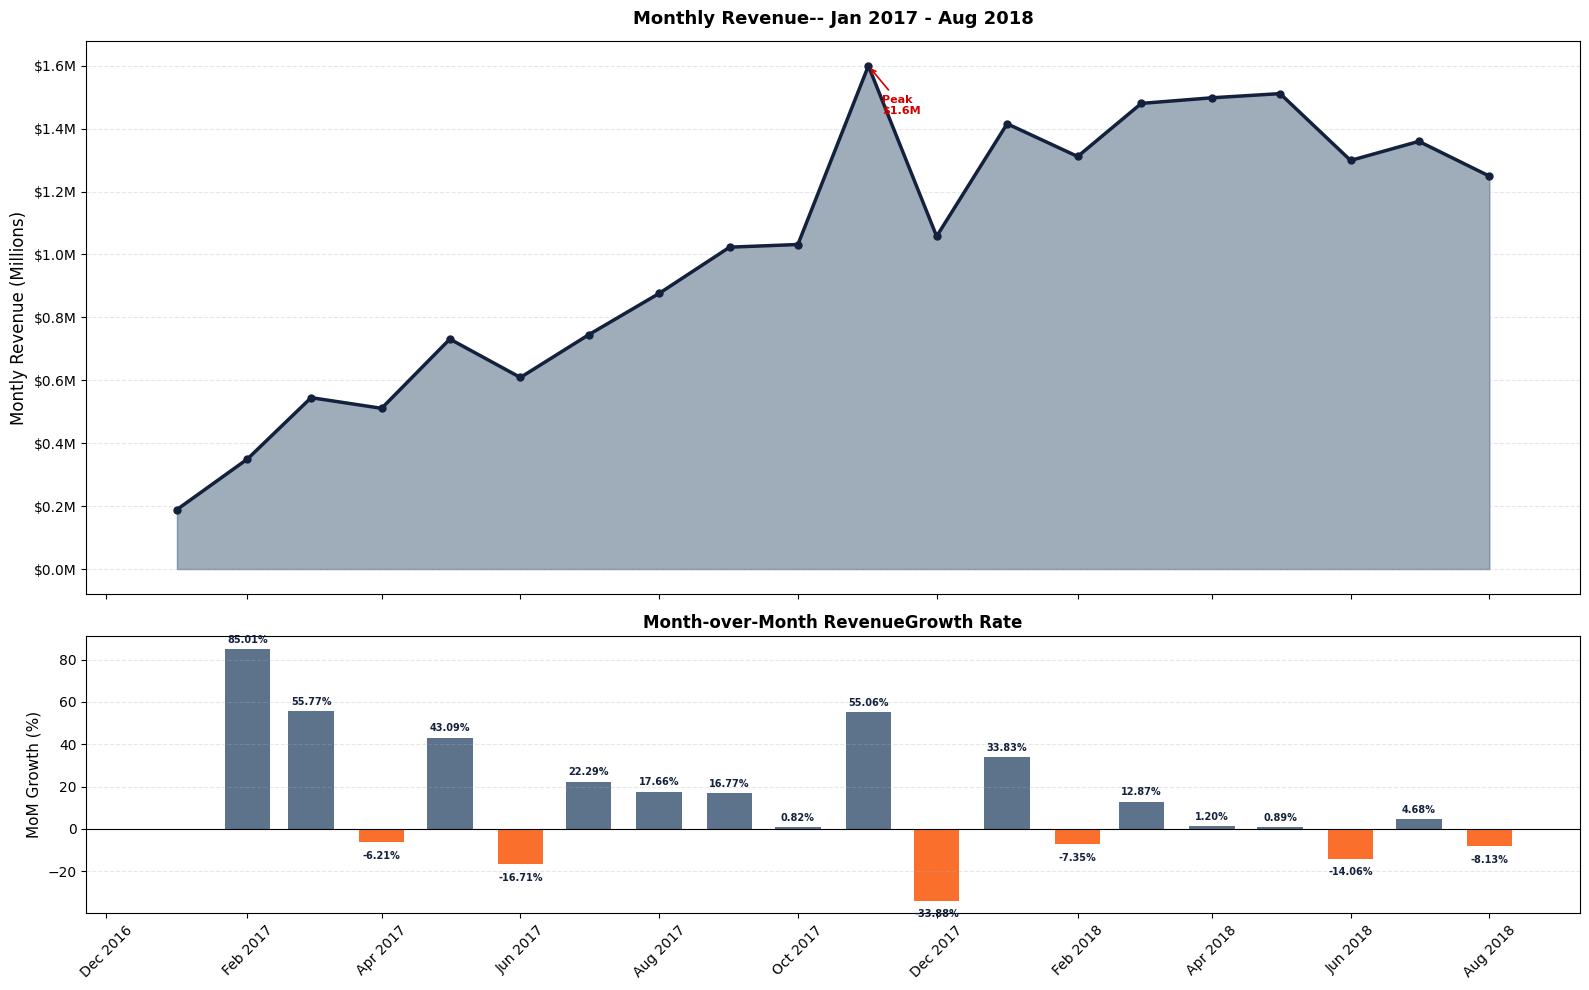

In [ ]:
fig, (ax1 , ax2) = plt.subplots(
    2,1,
    figsize=(16,10),
    sharex=True,
  
)

revenue_millions = monthly_revenue['payment_value'] / 1e6
monthly_revenue['order_month'] = pd.to_datetime(monthly_revenue['order_month'])
month_dt = monthly_revenue['order_month']

ax1.plot(
    month_dt, revenue_millions,
    color=COLOUR_PRIMARY, linewidth=2.5,
    marker='o', markersize=5, zorder=3
)

ax1.fill_between(month_dt, revenue_millions, alpha=0.5, color=COLOUR_ACCENT)

peak_ann = monthly_revenue['payment_value'].idxmax()
peak_x = month_dt[peak_ann]
peak_y = revenue_millions[peak_ann]

ax1.annotate(
    f"Peak\n${peak_y:.1f}M",
    xy=(peak_x,peak_y),
    xytext=(10,-35),
    textcoords='offset points',
    fontsize=8, color=COLOUR_EMPHASIS, fontweight='semibold',
    arrowprops=dict(arrowstyle='->' , color=COLOUR_EMPHASIS, lw=1.2)
)

ax1.set_ylabel('Montly Revenue (Millions)', fontsize=12)
ax1.set_title(
    'Monthly Revenue-- '
    'Jan 2017 - Aug 2018',
    fontsize=13, fontweight='bold', pad=12
)
ax1.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x:.1f}M') 
)
ax1.grid(axis='y', alpha=0.3, linestyle='--')

growth_data = monthly_revenue['mom_growth_pct'].fillna(0)
bar_colors = [
    COLOUR_ACCENT if x>= 0 else COLOUR_HIGHLIGHT for x in growth_data
]

ax2.bar(month_dt, growth_data, color=bar_colors, width=20 , alpha=0.85)
ax2.axhline(y=0 ,color='black', linewidth=0.8)

for x , y in zip(month_dt, growth_data):
    if y != 0 : ax2.text (
        x,y + (2 if y >= 0 else -4 ),
        f'{y:.2f}%',
        ha='center', va='bottom' if y >= 0 else'top',
        fontsize=7, color=COLOUR_PRIMARY, fontweight='semibold',
    )
        
ax2.set_ylabel('MoM Growth (%)', fontsize=11)
ax2.set_title('Month-over-Month RevenueGrowth Rate', fontsize=12, fontweight='bold')
ax2.grid(axis='y', alpha=0.3, linestyle='--')

ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()